#### 45 customers/hour / 60 minutes/hour = 0.75 customers/hour (arrival rate)

#### 50-50 chance of heading to the cashier or the ATM

#### Service at the ATM follows a triangular distribution with minimum duration of 1 minute, maximum duration of 4 minutes, and a mode duration of 2 minutes

In [67]:
import numpy as np
np.random.triangular(left=1, mode=2, right=4)

2.7762161221318182

#### Service at the cashier also follows a triangular distribution with minimum duration of 3 minutes, maximum duration of 20 minutes, and a mode duration of 5 minutes

In [68]:
np.random.triangular(left=3, mode=5, right=20)

13.530819797376891

#### 1st possibility/change mentioned - hiring a sixth cashier 

#### Comparing the second possibility

#### Training the 5 cashiers so that the maximum service time at a cashier becomes only 10 minutes instead of 20 minutes.

In [69]:
np.random.triangular(left=3, mode=5, right=10)

8.758313401594501

### For customers that first go to the ATM
- 30% chance each customer will then go see a cashier and
- 70% chance the customer will exit the bank immediately after ATM service.

### Baseline System 
- 1 ATM Machine
- 5 cashiers
- single cashier queue

In [70]:
# import statements
%pip install simpy

import simpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# SimPy Bank model - main simulation model

In [71]:
class BankSimulation:
    def __init__(self, sim_time, arrival_rate=0.75, num_cashiers=5, cashier_max=20, random_seed=10):
        self.sim_time = sim_time
        # arrival rate = 45 customers per hour / 60 minutes per hour = 0.75 customers per hour
        # arrival rate calculated above 
        self.arrival_rate = arrival_rate
        self.num_cashiers = num_cashiers
        self.cashier_max = cashier_max
        # added random seed for reproducibility
        self.rng = np.random.default_rng(random_seed)
        self.env = simpy.Environment()
        self.random_seed = random_seed

        # Resources creates bank's limited resource 
        # The ATM has capacity 1 as only one customer can use it at a time
        # The cashier resource has capacity 5 in the baseline because there are five cashiers sharing one queue.
        self.atm = simpy.Resource(self.env, capacity=1)
        self.cashiers = simpy.Resource(self.env, capacity=num_cashiers)

        # Customer-level metrics
        self.time_in_bank = []
        self.completion_times = []

        # System monitoring metrics
        self.monitor_times = []
        self.atm_queue_lengths = []
        self.cashier_queue_lengths = []
        self.busy_atm = []
        self.busy_cashiers = []

    # Service at the ATM follows a triangular distribution with minimum duration of 1 minute, 
    # maximum duration of 4 minutes, and a mode duration of 2 minutes
    def atm_service_time(self):
        return self.rng.triangular(left=1, mode=2, right=4)

    # Service at the cashier also follows a triangular distribution with minimum duration of 3 minutes, 
    # maximum duration of 20 minutes, and a mode duration of 5 minutes
    def cashier_service_time(self):
        return self.rng.triangular(left=3, mode=5, right=self.cashier_max)

    def customer_process(self):
        arrival_time = self.env.now

        # 50% chance customer goes to ATM first
        if self.rng.random() < 0.50:
            with self.atm.request() as request:
                yield request
                yield self.env.timeout(self.atm_service_time())

            # After ATM, 30% go to cashier
            if self.rng.random() < 0.30:
                yield self.env.process(self.visit_cashier())

        # 50% chance customer goes directly to cashier
        else:
            yield self.env.process(self.visit_cashier())

        # Customer exits the bank
        total_time = self.env.now - arrival_time
        self.time_in_bank.append(total_time)
        self.completion_times.append(self.env.now)

    def visit_cashier(self):
        with self.cashiers.request() as request:
            yield request
            yield self.env.timeout(self.cashier_service_time())

    def generate_arrivals(self):
        while True:
            # Exponential interarrival time
            # created customers randomly over time 
            # Because customers arrive randomly, we use an exponential distribution for time between arrivals.
            interarrival_time = self.rng.exponential(1 / self.arrival_rate)
            yield self.env.timeout(interarrival_time)

            self.env.process(self.customer_process())

    def monitor_system(self):
        while True:
            self.monitor_times.append(self.env.now)

            self.atm_queue_lengths.append(len(self.atm.queue))
            self.cashier_queue_lengths.append(len(self.cashiers.queue))

            self.busy_atm.append(len(self.atm.users))
            self.busy_cashiers.append(len(self.cashiers.users))

            # Record system state every 1 minute
            yield self.env.timeout(1)

    def run(self):
        self.env.process(self.generate_arrivals())
        self.env.process(self.monitor_system())
        self.env.run(until=self.sim_time)

# Function to run one scenario 

This function runs the simulation and calculates the required metrics.

Simulated for 300 days 

In [72]:
def run_scenario(num_cashiers=5, cashier_max=20, seed=10):
    # Simulate 300 days
    sim_time = 60 * 24 * 300
    bank = BankSimulation(sim_time=sim_time,arrival_rate=0.75,num_cashiers=num_cashiers,cashier_max=cashier_max,random_seed=seed)
    bank.run()

    time_in_bank = np.array(bank.time_in_bank)
    cashier_utilization = np.mean(np.array(bank.busy_cashiers)) / num_cashiers
    atm_utilization = np.mean(np.array(bank.busy_atm))
    mean_cashier_queue = np.mean(np.array(bank.cashier_queue_lengths))
    mean_atm_queue = np.mean(np.array(bank.atm_queue_lengths))

    results = {
        "Cashier Utilization": cashier_utilization,
        "ATM Utilization": atm_utilization,
        "Mean Cashier Queue Length": mean_cashier_queue,
        "Mean ATM Queue Length": mean_atm_queue,
        "Mean Time in Bank": np.mean(time_in_bank),
        "Median Time in Bank": np.median(time_in_bank),
        "Time in Bank Data": time_in_bank
    }

    return results

# Running the three scenarios

- Baseline: 5 cashiers, max cashier service time = 20
- Add 6th cashier: 6 cashiers, max cashier service time = 20
- Train cashiers: 5 cashiers, max cashier service time = 10

In [73]:
baseline = run_scenario(num_cashiers=5, cashier_max=20, seed=10)
six_cashiers = run_scenario(num_cashiers=6, cashier_max=20, seed=10)
trained_cashiers = run_scenario(num_cashiers=5, cashier_max=10, seed=10)

# Results Table

In [74]:
summary_table = pd.DataFrame({
    "Baseline: 5 Cashiers": {
        "Cashier Utilization": baseline["Cashier Utilization"],
        "ATM Utilization": baseline["ATM Utilization"],
        "Mean Cashier Queue Length": baseline["Mean Cashier Queue Length"],
        "Mean ATM Queue Length": baseline["Mean ATM Queue Length"],
        "Mean Time in Bank": baseline["Mean Time in Bank"],
        "Median Time in Bank": baseline["Median Time in Bank"],
    },
    "Add 6th Cashier": {
        "Cashier Utilization": six_cashiers["Cashier Utilization"],
        "ATM Utilization": six_cashiers["ATM Utilization"],
        "Mean Cashier Queue Length": six_cashiers["Mean Cashier Queue Length"],
        "Mean ATM Queue Length": six_cashiers["Mean ATM Queue Length"],
        "Mean Time in Bank": six_cashiers["Mean Time in Bank"],
        "Median Time in Bank": six_cashiers["Median Time in Bank"],
    },
    "Train Cashiers": {
        "Cashier Utilization": trained_cashiers["Cashier Utilization"],
        "ATM Utilization": trained_cashiers["ATM Utilization"],
        "Mean Cashier Queue Length": trained_cashiers["Mean Cashier Queue Length"],
        "Mean ATM Queue Length": trained_cashiers["Mean ATM Queue Length"],
        "Mean Time in Bank": trained_cashiers["Mean Time in Bank"],
        "Median Time in Bank": trained_cashiers["Median Time in Bank"],
    }
})

summary_table.round(3)

,Baseline: 5 Cashiers,Add 6th Cashier,Train Cashiers
Cashier Utilization,0.907,0.758,0.585
ATM Utilization,0.873,0.876,0.875
Mean Cashier Queue Length,4.230,0.782,0.160
Mean ATM Queue Length,3.133,3.368,3.231
Mean Time in Bank,17.072,12.765,9.585
Median Time in Bank,14.094,10.769,7.020


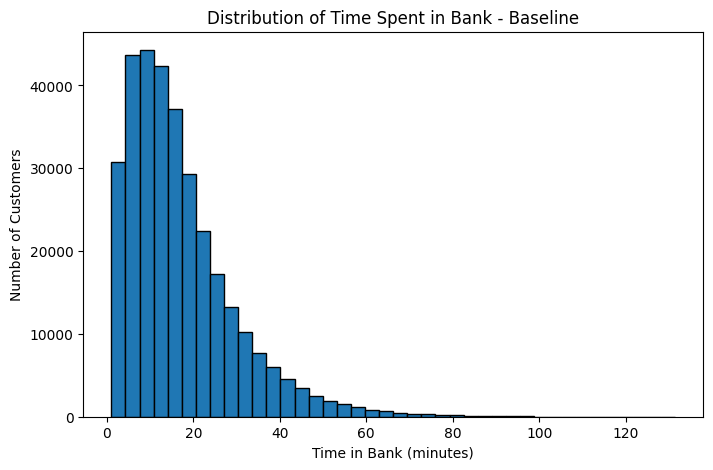

In [75]:
plt.figure(figsize=(8, 5))
plt.hist(baseline["Time in Bank Data"], bins=40, edgecolor="black")
plt.title("Distribution of Time Spent in Bank - Baseline")
plt.xlabel("Time in Bank (minutes)")
plt.ylabel("Number of Customers")
plt.show()

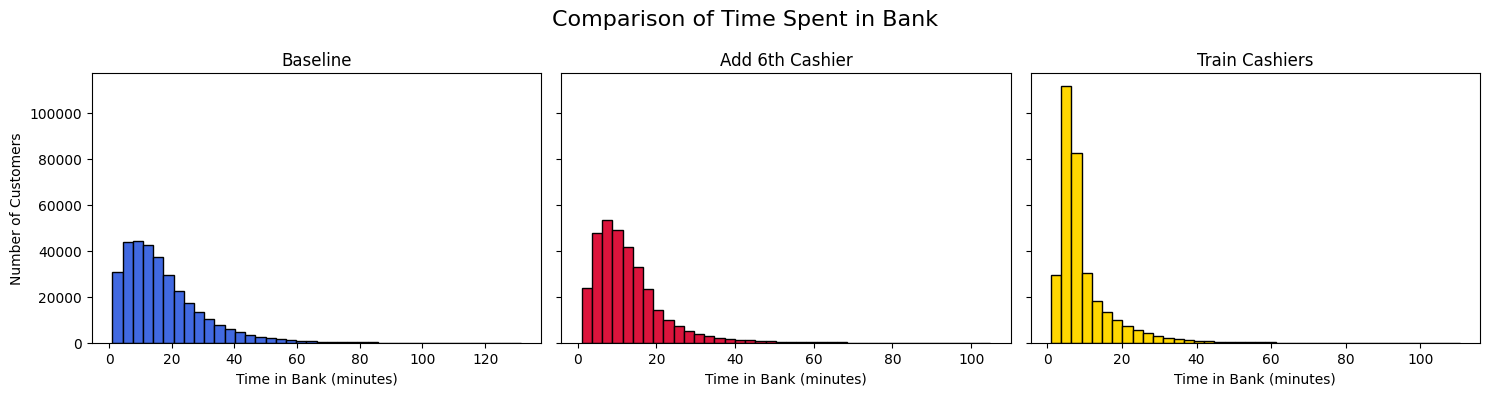

In [76]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

axes[0].hist(
    baseline["Time in Bank Data"],
    bins=40,
    color="royalblue",
    edgecolor="black"
)
axes[0].set_title("Baseline")
axes[0].set_xlabel("Time in Bank (minutes)")
axes[0].set_ylabel("Number of Customers")

axes[1].hist(
    six_cashiers["Time in Bank Data"],
    bins=40,
    color="crimson",
    edgecolor="black"
)
axes[1].set_title("Add 6th Cashier")
axes[1].set_xlabel("Time in Bank (minutes)")

axes[2].hist(
    trained_cashiers["Time in Bank Data"],
    bins=40,
    color="gold",
    edgecolor="black"
)
axes[2].set_title("Train Cashiers")
axes[2].set_xlabel("Time in Bank (minutes)")

fig.suptitle("Comparison of Time Spent in Bank", fontsize=16)
plt.tight_layout()
plt.show()

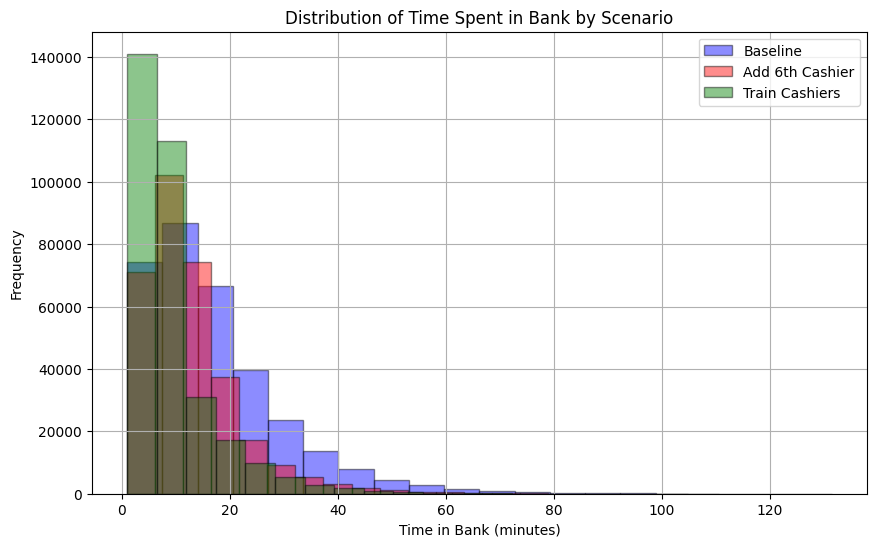

Baseline mean time in bank: 17.07 minutes
Add 6th cashier mean time in bank: 12.77 minutes
Train cashiers mean time in bank: 9.59 minutes


In [77]:
plt.figure(figsize=(10, 6))

plt.hist(
    baseline["Time in Bank Data"],
    bins=20,
    color="blue",
    edgecolor="black",
    alpha=0.45,
    label="Baseline"
)

plt.hist(
    six_cashiers["Time in Bank Data"],
    bins=20,
    color="red",
    edgecolor="black",
    alpha=0.45,
    label="Add 6th Cashier"
)

plt.hist(
    trained_cashiers["Time in Bank Data"],
    bins=20,
    color="green",
    edgecolor="black",
    alpha=0.45,
    label="Train Cashiers"
)

plt.title("Distribution of Time Spent in Bank by Scenario")
plt.xlabel("Time in Bank (minutes)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

print(f"Baseline mean time in bank: {np.mean(baseline['Time in Bank Data']):.2f} minutes")
print(f"Add 6th cashier mean time in bank: {np.mean(six_cashiers['Time in Bank Data']):.2f} minutes")
print(f"Train cashiers mean time in bank: {np.mean(trained_cashiers['Time in Bank Data']):.2f} minutes")

### Training the existing 5 cashiers is more effective because it reduces the mean time in bank the most, from 17.07 minutes to 9.59 minutes. It also lowers the mean cashier queue length from 4.23 customers to only 0.16 customers, which is a bigger improvement than adding a sixth cashier. The main bottleneck is the long cashier service time, so reducing the maximum service time from 20 to 10 minutes improves the system more than simply adding capacity.